In [ ]:
import jax

jax.config.update("jax_enable_x64", True)

import copy
from functools import partial
from pathlib import Path
from typing import Callable

import equinox as eqx
import gstools as gs
import imageio_ffmpeg
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import HTML
from jax.experimental import checkify
from jax_tqdm import scan_tqdm
from scipy.io import loadmat
from tqdm.auto import tqdm, trange

from nanopinv.distribution import MultivariateNormalCholesky
from nanopinv.physics_jax import build_time_travel_points
from nanopinv.sampler_jax import (
    ExtendedMetropolisChain,
    ParallelTemperingSampler,
    ProposalDistribution,
)
from nanopinv.utils import StatefulRNGKey, make_pytree_spec
from nanopinv.variance import get_distance_matrix, spherical

mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

%load_ext autoreload
%autoreload 2

In [2]:
# Load dataset
M = loadmat("AM13_data.mat")

N_data, N_dim = M["S"].shape
sources = jnp.asarray(M["S"])  # Shape: (N_data, N_dim)
receivers = jnp.asarray(M["R"])  # Shape: (N_data, N_dim)
assert sources.shape == receivers.shape, (
    "Sources and receivers must have the same shape."
)

data_obs = M["d_obs"].flatten()
data_std = M["d_std"].flatten()
data_std = 0.4 * np.ones_like(
    data_obs
)  # For whatever reason, we overwrite this, maybe original data was wrong?

print(f"Number of data points: {N_data}")
print(f"Number of dimensions: {N_dim}")

Number of data points: 702
Number of dimensions: 2


In [ ]:
# Set up grid


dx = 0.135
x = jnp.arange(-2 * dx, 5 + 2 * dx, dx)
y = jnp.arange(1 - 2 * dx, 12 + 2 * dx, dx)
r = (
    x,
    y,
)
grid_shape = (
    len(x),
    len(y),
)

# Set up prior
m0 = 0.12
range_ = 7.0
partial_sill = 0.00003
nugget = 1e-10

h = get_distance_matrix(*r)
cov = spherical(h, range_=range_, partial_sill=partial_sill, nugget=nugget)
prior = MultivariateNormalCholesky(shape=grid_shape, cov=cov, mean=m0)

# Set up forward model
forward_model = build_time_travel_points(sources, receivers, x, y)

# Set up proposal distribution
proposal_dist = ProposalDistribution(dist=prior, step_size=0.01)

# Set up RNG
rng_key = jax.random.PRNGKey(0)
skey = StatefulRNGKey(0)

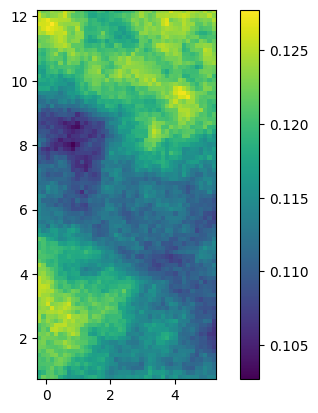

In [4]:
realisation = prior(rng_key)

plt.imshow(
    realisation.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar()

In [5]:
# num_frames = 20

# # batch_samples will have shape (num_frames, nx, ny)
# batch_samples = prior(rng_key, num_samples=num_frames)  # Shape: (num_frames, nx, ny)

# # 2. Build the animation
# fig, ax = plt.subplots(figsize=(6, 8))

# # We keep track of the Artist objects for the animation
# ims = []
# for i in range(num_frames):
#     # .T to transpose since JAX indexing is 'ij' (x, y)
#     # but imshow expects (y, x)
#     im = ax.imshow(batch_samples[i].T, origin="lower", animated=True, cmap="viridis")
#     ims.append([im])

# # Add a colorbar (optional, but good for relative magnitudes)
# plt.colorbar(ims[0][0], ax=ax, label="Velocity variation")

# # 3. Compile to video
# ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True, repeat_delay=1000)
# plt.close()  # Prevent showing a static empty plot below the video

# # Display in notebook
# HTML(ani.to_html5_video())

In [6]:
# current_state = prior(rng_key)


# sampler = ExtendedMetropolisSampler(
#     n_samples=1000,
#     n_chains=4,
#     n_burn_in=200,
#     temperatures=1.0,

#     proposal_dist=proposal_dist,
#     current_state=current_state,
# )



In [7]:
# sampler_vec = jax.vmap(ExtendedMetropolisSampler)
# sampler_vec()

# rng_key, sample_key = jax.random.split(rng_key)

# prior_vec = jax.vmap(jax.vmap(prior))
# current_states = prior_vec(skey.shaped((4, 3)))
# sampler_vec = jax.vmap(jax.vmap(sampler.sample))
# samples = sampler_vec(current_states, skey.shaped((4, 3)))
# # # current_states_key =
# # current_states = prior(skey(), num_samples=3)
# # samples = sampler.sample(current_states, skey(3))
# # # current_states.shape
# # # skey(3).shape
# # samples.shape
# samples.shape

In [ ]:
# travel_times = forward_model(batch_samples)  # Shape: (num_frames, N_data)
# travel_times.shape

In [ ]:
@jax.jit
def log_likelihood_gaussian(data_obs, data_std, data_pred):
    normalised_residual = (data_obs - data_pred) / data_std
    log_likelihood = -0.5 * jnp.sum(normalised_residual**2)
    return jnp.sum(log_likelihood)


chain = ExtendedMetropolisChain(
    temperature=1.0,
    proposal_dist=proposal_dist,
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)

In [ ]:
temperatures = jnp.array([1.0, 2.0, 4.0])
N_steps = 250

ExtendedMetropolisChain(
  temperature=f64[3],
  proposal_dist=ProposalDistribution(
    dist=MultivariateNormalCholesky(
      mean=weak_f64[3,1], shape=(42, 86), L=f64[3,3612,3612]
    ),
    step_size=weak_f64[3],
    mean=weak_f64[3,1]
  ),
  forward_model=<PjitFunction>,
  likelihood=<PjitFunction of <function log_likelihood_gaussian at 0x000001E1C99A1F30>>
)

In [11]:
# # --- 1. Instantiate as normal (no vmap needed here) ---
# chains = ExtendedMetropolisChain(
#     temperature=temperatures,            # Batched: e.g. shape (3,)
#     proposal_dist=proposal_dist,         # Unbatched!
#     forward_model=forward_model,
#     likelihood=log_likelihood_gaussian,
#     data_obs=data_obs,
#     data_std=data_std,
# )

# # --- 2. Build the vmap axes safely ---
# # Step A: Use the original tree so `tree_at` can uniquely identify the leaf.
# # Replace the temperature leaf with a unique string marker.
# marked_chains = eqx.tree_at(lambda c: c.temperature, chains, "BATCH_ME")

# # Step B: Map over the tree. If the leaf is our marker, map it to axis 0.
# # Otherwise, map it to None (do not batch).
# chain_axes = jax.tree_util.tree_map(
#     lambda x: 0 if (isinstance(x, str) and x == "BATCH_ME") else None,
#     marked_chains
# )

# display(chain_axes)

# # def extended_metropolis_chain_filter_spec(leaf):
# #     print(leaf)
# #     if leaf == ExtendedMetropolisChain.temperature:
# #         return 0  # Batch over temperatures
# #     else:
# #         return None  # Do not batch other fields

# extended_metropolis_chain_filter_spec = {
#     "temperature": 0,
#     "proposal_dist": None,
#     "forward_model": None,
#     "likelihood": None,
#     "data_obs": None,
#     "data_std": None,
# }

# # --- 3. Vmap your execution step ---
# # @partial(
# #     jax.vmap,
# #     #        chain,      key, state_curr, log_L_curr, data_obs, data_std
# #     in_axes=(extended_metropolis_chain_filter_spec, 0,   0,          0,          None,     None)
# #     # in_axes=(chain_axes, 0,   0,          0,          None,     None)
# # )

# extended_metropolis_chain_filter_spec = ExtendedMetropolisChain(
#     temperature=0,                        # 0: Batch this field
#     proposal_dist=None,                   # None: JAX will apply None to everything inside the proposal_dist subtree
#     data_obs=None,                        # None: Do not batch
#     data_std=None,                        # None: Do not batch

#     # --- THE GOLDEN RULE FOR STATIC FIELDS ---
#     # You MUST pass the exact same functions you pass to the real object.
#     # You cannot pass `None` here, otherwise JAX will say the trees don't match!
#     forward_model=forward_model,
#     likelihood=log_likelihood_gaussian,
# )

# @eqx.filter_vmap(in_axes=(extended_metropolis_chain_filter_spec, 0,   0,          0,          None,     None))
# def step_chains(chain: ExtendedMetropolisChain, key, state_curr, log_L_curr, data_obs, data_std):
#     return chain(key, state_curr, log_L_curr, data_obs, data_std)

# # --- 4. Run it ---
# N_chains = len(temperatures)
# keys = jax.random.split(jax.random.PRNGKey(0), N_chains)
# # Replace 42, 86 with your actual "*grid" shape!

# states = prior(skey(), num_samples=N_chains)

# # And your log likelihoods start at 0 (or whatever initial value)
# log_Ls = jnp.zeros((N_chains,))

# # Now the execution will work:
# new_proposals = step_chains(chains, keys, states, log_Ls, data_obs, data_std)

# chains



In [12]:
# from functools import partial

# import jax
# import jax.numpy as jnp
# from jax.tree_util import GetAttrKey

# # 1. Instantiate the module normally (NO VMAP HERE!)
# # The heavy proposal_dist matrix remains a single, shared object in memory.
# chains = ExtendedMetropolisChain(
#     temperature=temperatures,            # Batched shape: (N_chains,)
#     proposal_dist=proposal_dist,         # Unbatched heavy object
#     forward_model=forward_model,         # Static (ignored by JAX)
#     likelihood=log_likelihood_gaussian,  # Static (ignored by JAX)
#     data_obs=data_obs,                   # Unbatched
#     data_std=data_std,                   # Unbatched
# )

# # 2. Build the in_axes spec using JAX Key Paths
# def match_key_path(path, leaf):
#     # `path` is a tuple representing the route to the leaf.
#     # `path[0]` is the top-level attribute name of the `chains` object.
#     if len(path) > 0 and isinstance(path[0], GetAttrKey) and path[0].name == "temperature":
#         return 0  # Apply batch axis 0 to this field
#     return None   # Apply None (do not batch) to everything else

# chain_axes = jax.tree_util.tree_map_with_path(match_key_path, chains)

# # 3. Define the vmapped execution step
# @partial(
#     jax.vmap,
#     #        chain,      key, state_curr, log_L_curr, data_obs, data_std
#     in_axes=(chain_axes, 0,   0,          0,          None,     None)
# )
# def step_chains(chain, key, state_curr, log_L_curr, data_obs, data_std):
#     return chain(key, state_curr, log_L_curr, data_obs, data_std)

# # --- 4. Run it ---
# N_chains = len(temperatures)
# keys = jax.random.split(jax.random.PRNGKey(0), N_chains)
# # Replace 42, 86 with your actual "*grid" shape!

# states = prior(skey(), num_samples=N_chains)

# # And your log likelihoods start at 0 (or whatever initial value)
# log_Ls = jnp.zeros((N_chains,))

# # Now the execution will work:
# new_proposals = step_chains(chains, keys, states, log_Ls, data_obs, data_std)

# chains

# chain_axes


In [ ]:
proposal_dist = ProposalDistribution(dist=prior, step_size=0.1)

N_chains = 3
temperatures = jnp.geomspace(1.0, 10.0, N_chains)
chains = ExtendedMetropolisChain(
    temperature=temperatures,  # Batched: e.g. shape (3,)
    proposal_dist=proposal_dist,  # Unbatched!
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)

state_current = prior(skey(), num_samples=N_chains)
log_L_current = jax.vmap(log_likelihood_gaussian, in_axes=(None, None, 0))(
    data_obs, data_std, forward_model(state_current)
)

spec = make_pytree_spec(
    chains,
    {
        "temperature": 0,
        "*": None,
    },
)


@partial(jax.vmap, in_axes=(0, spec, 0, 0))
def step_chains(key, chain: ExtendedMetropolisChain, current_state, log_L_current):
    return chain(key, current_state, log_L_current, data_obs, data_std)


current_state, log_L_current, accepted = step_chains(
    skey(N_chains), chains, state_current, log_L_current
)

history_log_L_current = []
history_accept = []

In [ ]:
current_state, log_L_current, accepted = step_chains(
    skey(N_chains), chains, state_current, log_L_current
)
history_log_L_current.append(log_L_current)
history_accept.append(accepted)
print(log_L_current, accepted)

[-507.58731018 -490.7990986  -484.86799471] [ True False  True]


In [ ]:
# @partial(jax.vmap, in_axes=(None, 0, None, None, None))
@partial(jax.vmap, in_axes=(None, 0, spec, 0, 0))
def step_chains_n(n, key, chain: ExtendedMetropolisChain, current_state, log_L_current):
    return chain.step_n(
        n, key, current_state, log_L_current, data_obs, data_std, progress=True
    )


keys = skey.shaped((N_chains,))
(current_state, log_L_current), history = step_chains_n(
    N_steps, keys, chains, state_current, log_L_current
)

Sampling:   0%|          | 0/250 [00:00<?, ?it/s]

In [16]:
len(history)
history[1].shape

(3, 250)

In [17]:
history_log_L_current = []
history_accept = []

history_log_L_current = history[1]
history_accepted = history[2]

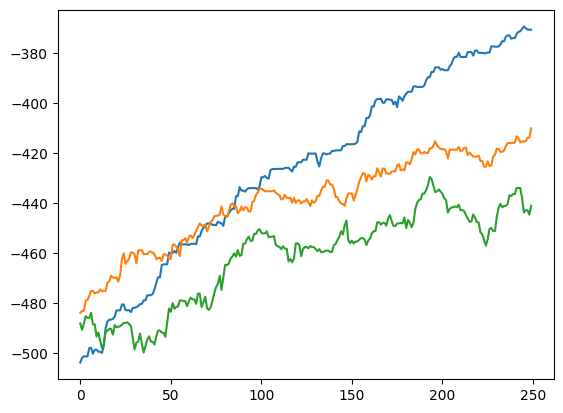

In [18]:
plt.plot(history_log_L_current.T)

In [ ]:
proposal_dist_high = ProposalDistribution(dist=prior, step_size=0.2)
chain = ExtendedMetropolisChain(
    temperature=1.0,
    proposal_dist=proposal_dist_high,
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)

state_current = prior(skey())
log_L_current = log_likelihood_gaussian(
    data_obs, data_std, forward_model(state_current)
)

n_steps_tune = 50
key = skey()
target_acceptance_rate = 0.25
tune_interval = 25
learning_rate = 1.0
learning_rate_decay = 0.5


tuner = checkify.checkify(chain.tune)
err, (tuned_chain, history) = tuner(
    n_steps_tune=n_steps_tune,
    tune_interval=tune_interval,
    key=key,
    state_current=state_current,
    log_L_current=log_L_current,
    data_obs=data_obs,
    data_std=data_std,
    target_acceptance_rate=target_acceptance_rate,
    learning_rate=0.1,
    learning_rate_decay=0.5,
    progress=True,
)
err.throw()

Tuning:   0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
temperatures = jnp.array([1.0, 2.0, 3.0])
step_sizes = jnp.array([0.1, 0.2, 0.3])

base_chain = ExtendedMetropolisChain(
    temperature=1.0,  # Placeholder, will be overridden by vmap
    proposal_dist=proposal_dist,  # Unbatched heavy object
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)


proposal_dists = ProposalDistribution(
    dist=prior,  # Unbatched heavy object
    step_size=step_sizes,  # Batched over step sizes
)

spec_proposal_dist = make_pytree_spec(
    proposal_dists,
    {
        "step_size": 0,  # Batch over step sizes
        "*": None,
    },
)

spec_chain = make_pytree_spec(
    base_chain,
    {
        "temperature": 0,  # Batch over temperatures
        "proposal_dist": spec_proposal_dist,  # Use the proposal_dist spec for the proposal_dist subtree
        "*": None,
    },
)
# @partial(jax.vmap, in_axes=(0, spec_proposal_dist), out_axes=spec_chain)
# def make_chains(temperature, proposal_dist):
#     return ExtendedMetropolisChain(
#         temperature=temperature,            # Batched: e.g. shape (3,)
#         proposal_dist=proposal_dist,         # Unbatched!
#         forward_model=forward_model,
#         likelihood=log_likelihood_gaussian,
#     )

# chains = make_chains(temperatures, proposal_dists)

chains = ExtendedMetropolisChain(
    temperature=temperatures,  # Batched: e.g. shape (3,)
    proposal_dist=proposal_dists,  # Unbatched!
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)

from nanopinv.sampler_jax import ParallelTemperingSampler

pt = ParallelTemperingSampler(
    chains=chains,
    swap_interval=10,
)

states_current = prior(skey(), num_samples=len(temperatures))
log_Ls_current = jax.vmap(log_likelihood_gaussian, in_axes=(None, None, 0))(
    data_obs, data_std, forward_model(states_current)
)

out = pt(
    key=skey(),
    state_current=states_current,
    log_L_current=log_Ls_current,
    data_obs=data_obs,
    data_std=data_std,
)

In [21]:
out = pt(
    key=skey(),
    state_current=states_current,
    log_L_current=log_Ls_current,
    data_obs=data_obs,
    data_std=data_std,
)
out

(Array([[[0.1297797 , 0.12844269, 0.12686927, ..., 0.12872855,
          0.12826759, 0.12944159],
         [0.12659288, 0.12657756, 0.12412866, ..., 0.12839911,
          0.12926847, 0.128967  ],
         [0.12523305, 0.12504823, 0.12478412, ..., 0.13062231,
          0.13025704, 0.13080034],
         ...,
         [0.11636075, 0.11518495, 0.11483829, ..., 0.1122994 ,
          0.11396405, 0.11394662],
         [0.11842363, 0.11497063, 0.11476529, ..., 0.11315967,
          0.11405116, 0.1155582 ],
         [0.11683617, 0.11555621, 0.11385174, ..., 0.11235839,
          0.11332738, 0.11499016]],
 
        [[0.11660793, 0.11736497, 0.1165585 , ..., 0.11402393,
          0.11739128, 0.11994289],
         [0.11724625, 0.11712785, 0.11668506, ..., 0.11679341,
          0.11901086, 0.12010626],
         [0.11577575, 0.11566688, 0.11663912, ..., 0.11756585,
          0.1182269 , 0.12108527],
         ...,
         [0.11725384, 0.11466717, 0.1149524 , ..., 0.11848734,
          0.11617539, 0.

In [23]:
pt(
    key=skey(),
    state_current=state_current,
    log_L_current=log_L_current,
    data_obs=data_obs,
    data_std=data_std,
)

ValueError: vmap was requested to map its argument along axis 0, which implies that its rank should be at least 1, but is only 0 (its shape is ())

In [ ]:
chain

ExtendedMetropolisChain(
  temperature=1.0,
  proposal_dist=ProposalDistribution(
    dist=MultivariateNormalCholesky(
      mean=weak_f64[1], shape=(42, 86), L=f64[3612,3612]
    ),
    step_size=weak_f64[],
    mean=weak_f64[1]
  ),
  forward_model=<PjitFunction>,
  likelihood=<PjitFunction of <function log_likelihood_gaussian at 0x0000017D8C7E6610>>
)

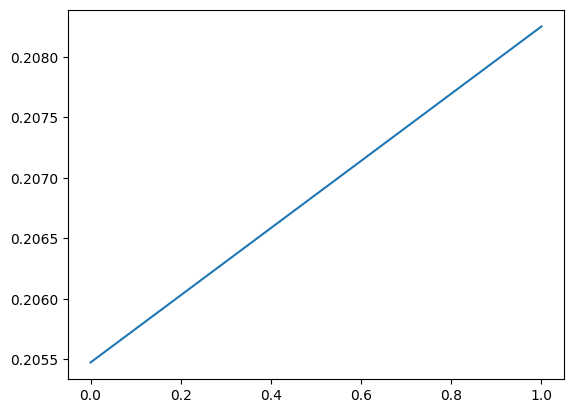

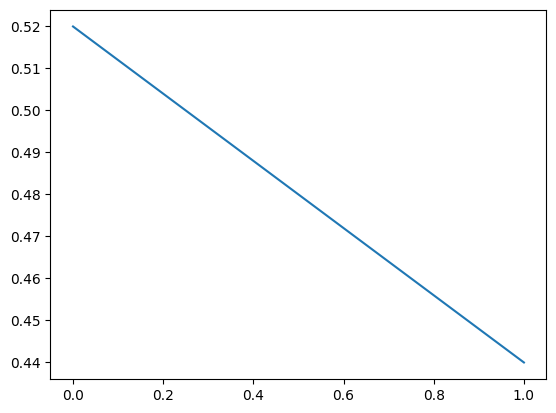

In [24]:
plt.plot(history[2])
plt.figure()
plt.plot(history[3])

In [25]:
out

(Array([[[0.1297797 , 0.12844269, 0.12686927, ..., 0.12872855,
          0.12826759, 0.12944159],
         [0.12659288, 0.12657756, 0.12412866, ..., 0.12839911,
          0.12926847, 0.128967  ],
         [0.12523305, 0.12504823, 0.12478412, ..., 0.13062231,
          0.13025704, 0.13080034],
         ...,
         [0.11636075, 0.11518495, 0.11483829, ..., 0.1122994 ,
          0.11396405, 0.11394662],
         [0.11842363, 0.11497063, 0.11476529, ..., 0.11315967,
          0.11405116, 0.1155582 ],
         [0.11683617, 0.11555621, 0.11385174, ..., 0.11235839,
          0.11332738, 0.11499016]],
 
        [[0.11660793, 0.11736497, 0.1165585 , ..., 0.11402393,
          0.11739128, 0.11994289],
         [0.11724625, 0.11712785, 0.11668506, ..., 0.11679341,
          0.11901086, 0.12010626],
         [0.11577575, 0.11566688, 0.11663912, ..., 0.11756585,
          0.1182269 , 0.12108527],
         ...,
         [0.11725384, 0.11466717, 0.1149524 , ..., 0.11848734,
          0.11617539, 0.

In [26]:
# Assuming ExtendedMetropolisChain and make_pytree_spec are available
class ParallelTemperingSampler(eqx.Module):
    chains: ExtendedMetropolisChain
    spec: jax.tree_util.PyTreeDef
    n_chains: int = eqx.field(static=True)

    def __init__(
        self,
        temperatures: jax.Array,
        proposal_dist,
        forward_model: Callable,
        likelihood: Callable,
    ):
        self.n_chains = len(temperatures)

        self.chains = ExtendedMetropolisChain(
            temperature=temperatures,
            proposal_dist=proposal_dist,
            forward_model=forward_model,
            likelihood=likelihood,
        )

        self.spec = make_pytree_spec(
            self.chains,
            {
                "temperature": 0,
                "*": None,
            },
        )

    def _swap_adjacent(self, key, states, log_Ls, offset):
        """
        Attempts to swap states and log-likelihoods between adjacent chains.
        offset=0 permits swaps on (0,1), (2,3). offset=1 permits (1,2), (3,4).
        By masking rather than dynamically slicing, we keep array sizes static.
        """
        idx1 = jnp.arange(self.n_chains - 1)
        idx2 = idx1 + 1

        log_L1 = log_Ls[idx1]
        log_L2 = log_Ls[idx2]
        T1 = self.chains.temperature[idx1]
        T2 = self.chains.temperature[idx2]

        # PT swap acceptance log-probability
        delta_log_L = log_L2 - log_L1
        delta_inv_T = (1.0 / T1) - (1.0 / T2)
        log_alpha = delta_log_L * delta_inv_T

        u = jax.random.uniform(key, shape=log_alpha.shape)

        # Accept if:
        # 1) standard metropolis criteria is met
        # 2) the index matches the current alternating offset (even or odd pair)
        accept = (jnp.log(u) < log_alpha) & ((idx1 % 2) == offset)

        def swap_if(x, accept_mask):
            # Scan iteratively to apply swaps sequentially.
            # Doing this ensures that if chained swaps were permitted, we don't clobber things,
            # but since we mask by parity (offset), no chain is swapped twice in one step.
            def step_fn(carry, i):
                arr = carry
                val1, val2 = arr[i], arr[i + 1]
                # If accept_mask[i] is True, swap the contents
                new_val1 = jnp.where(accept_mask[i], val2, val1)
                new_val2 = jnp.where(accept_mask[i], val1, val2)
                arr = arr.at[i].set(new_val1).at[i + 1].set(new_val2)
                return arr, None

            final_arr, _ = jax.lax.scan(step_fn, x, jnp.arange(self.n_chains - 1))
            return final_arr

        new_states = swap_if(states, accept)
        new_log_Ls = swap_if(log_Ls, accept)

        return new_states, new_log_Ls, jnp.sum(accept)

    @eqx.filter_jit
    def step(self, key, current_state, log_L_current, swap_offset):
        # 1. Standard MCMC step for all chains
        step_key, swap_key = jax.random.split(key)

        @partial(jax.vmap, in_axes=(0, self.spec, 0, 0))
        def _step_local(k, chain_b, state_b, log_L_b):
            # Assumes chain.__call__ returns standard MCMC inputs
            # Check cell 21 in your notebook for exact outputs; usually: state, log_L, accepted
            return chain_b(k, state_b, log_L_b, data_obs, data_std)

        keys = jax.random.split(step_key, self.n_chains)

        # Note: adjust this unpacking if your step function returns an accept array
        new_state, new_log_L, _ = _step_local(
            keys, self.chains, current_state, log_L_current
        )

        # 2. Replica exchange swap
        return self._swap_adjacent(swap_key, new_state, new_log_L, swap_offset)

    @eqx.filter_jit
    def step_n(self, n_steps, key, start_state, start_log_L):
        def _scan_fn(carry, step_key):
            state, log_L, i = carry

            # Alternate between even/odd swaps (i % 2) for detailed balance
            # E.g., step 0 -> offset 0, step 1 -> offset 1
            offset = i % 2

            next_state, next_log_L, num_swaps = self.step(
                step_key, state, log_L, offset
            )
            out = (next_state, next_log_L, num_swaps)

            return (next_state, next_log_L, i + 1), out

        keys = jax.random.split(key, n_steps)
        final_carry, history = jax.lax.scan(
            _scan_fn, (start_state, start_log_L, jnp.array(0, dtype=jnp.int32)), keys
        )

        # history contains (states_history, log_L_history, swap_count_history)
        return (final_carry[0], final_carry[1]), history


# --- Test the sampler ---
proposal_dist = ProposalDistribution(dist=prior, step_size=0.1)

N_chains = 4
temperatures = jnp.geomspace(1.0, 5.0, N_chains)
pt_sampler = ParallelTemperingSampler(
    temperatures=temperatures,
    proposal_dist=proposal_dist,
    forward_model=forward_model,
    likelihood=log_likelihood_gaussian,
)

# Setup initial distributions
state_current = prior(skey(), num_samples=N_chains)


# Use JIT and correctly vectorize log-L evaluation
@jax.jit
def get_initial_log_L(st):
    return jax.vmap(log_likelihood_gaussian, in_axes=(None, None, 0))(
        data_obs, data_std, forward_model(st)
    )


log_L_current = get_initial_log_L(state_current)

N_steps = 100
(final_state, final_log_L), history = pt_sampler.step_n(
    N_steps, skey(), state_current, log_L_current
)
states_hist, log_l_hist, swap_counts = history

In [27]:
samples = []
data = []
N_steps = 100
N_done = 0
N_accepted = 0

temperature = 1.0

rng_key = jax.random.PRNGKey(0)

rng_key, initial_key = jax.random.split(rng_key)

proposal_dist = ProposalDistribution(dist=prior, step_size=0.1)
state_current = prior(initial_key)
log_L_current = log_likelihood_gaussian(
    data_obs, data_std, forward_model(state_current)
)


@jax.jit(static_argnames=["forward_model"])
def do_step(
    key,
    state_current,
    log_L_current,
    proposal_dist: ProposalDistribution,
    data_obs,
    data_std,
    forward_model,
    temperature,
):
    proposal_key, accept_key = jax.random.split(key)

    state_proposal = proposal_dist.propose(
        key=proposal_key, state_current=state_current
    )

    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    log_P_accept = jnp.minimum(0.0, log_ratio)
    P_accept = jnp.exp(log_P_accept)

    accept = jax.random.uniform(accept_key) < P_accept

    state_next = jnp.where(accept[None, None], state_proposal, state_current)
    log_L_next = jnp.where(accept, log_L_proposal, log_L_current)

    return state_next, log_L_next, accept


for i in trange(N_steps):
    rng_key, iteration_key = jax.random.split(rng_key)
    state_current, log_L_current, accept = do_step(
        rng_key,
        state_current,
        log_L_current,
        proposal_dist,
        data_obs,
        data_std,
        forward_model,
        temperature,
    )

    N_accepted += jnp.sum(accept)
    N_done += 1

    samples.append(state_current.copy())

    data.append(
        {
            "step": N_done,
            "accepted": N_accepted,
            "acceptance_rate": N_accepted / N_done,
        }
    )

  0%|          | 0/100 [00:00<?, ?it/s]

In [28]:
import jax.lax as lax


# First, define your single step exactly as you did, slightly modified to
# package the inputs and outputs structurally for lax.scan
@jax.jit(static_argnames=["forward_model"])
def mcmc_scan_body(
    carry,  # The current state that carries over chain steps
    step_key,  # The specific pre-split rng key for this one iteration
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
):
    # Unpack the carry
    state_current, log_L_current = carry

    proposal_key, accept_key = jax.random.split(step_key)

    state_proposal = proposal_dist.propose(
        key=proposal_key, state_current=state_current
    )

    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    log_P_accept = jnp.minimum(0.0, log_ratio)
    P_accept = jnp.exp(log_P_accept)

    accept = jax.random.uniform(accept_key) < P_accept

    state_next = jnp.where(accept, state_proposal, state_current)
    log_L_next = jnp.where(accept, log_L_proposal, log_L_current)

    # Package the updated state for the next step
    new_carry = (state_next, log_L_next)

    # Let's save the current state and whether we accepted as the history arrays
    history_output = (state_next, log_L_next, accept)

    return new_carry, history_output


# Now, build wrapper that JIT compiles the full loop execution
@jax.jit(static_argnames=["forward_model", "N_steps"])
def run_mcmc_chain(
    rng_key,
    initial_state,
    initial_log_L,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
    N_steps,
):
    # Pre-generate ALL random keys for the entire chain simultaneously avoiding sequential splits
    keys = jax.random.split(rng_key, N_steps)

    # We must explicitly freeze static objects into the scan closure
    def scan_fn(carry, step_key):
        return mcmc_scan_body(
            carry,
            step_key,
            proposal_dist,
            data_obs,
            data_std,
            forward_model,
            temperature,
        )

    initial_carry = (initial_state, initial_log_L)

    # jax.lax.scan sequentially applies `scan_fn`.
    # It passes initial_carry and keys[0], gets new_carry_1 and out_1.
    # It passes new_carry_1 and keys[1], gets new_carry_2 and out_2...
    final_carry, history = lax.scan(scan_fn, initial_carry, keys)

    return final_carry, history


# --- RUNNING THE CHAIN ---
N_steps = 100

state_current = prior(initial_key)
log_L_current = log_likelihood_gaussian(
    data_obs, data_std, forward_model(state_current)
)

final_carry, (samples_j, log_L_j, accepts_j) = run_mcmc_chain(
    rng_key,
    state_current,
    log_L_current,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
    N_steps,
)

# Convert mapped history into numpy
samples = np.array(samples_j)
log_L_history = np.array(log_L_j)
accepts = np.array(accepts_j)

# You can reconstruct your stats DataFrame easily because
# standard numpy vector operations are faster than loop appends anyway
steps = np.arange(1, N_steps + 1)
cumulative_accepts = np.cumsum(accepts)

data = []
for i in range(N_steps):
    data.append(
        {
            "step": steps[i],
            "accepted": cumulative_accepts[i],
            "acceptance_rate": cumulative_accepts[i] / steps[i],
        }
    )

In [29]:
import jax.lax as lax


# 1. Provide the sequential building block (the scan body)
# This handles the logic for a single Markov step
def mcmc_scan_body(
    carry, step_key, proposal_dist, data_obs, data_std, forward_model, temperature
):
    state_current, log_L_current = carry

    proposal_key, accept_key = jax.random.split(step_key)

    state_proposal = proposal_dist.propose(
        key=proposal_key, state_current=state_current
    )

    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    log_P_accept = jnp.minimum(0.0, log_ratio)
    P_accept = jnp.exp(log_P_accept)

    accept = jax.random.uniform(accept_key) < P_accept

    state_next = jnp.where(accept, state_proposal, state_current)
    log_L_next = jnp.where(accept, log_L_proposal, log_L_current)

    new_carry = (state_next, log_L_next)
    history_output = (state_next, log_L_next, accept)

    return new_carry, history_output


# 2. Build the unmapped single-chain runner.
# Do NOT apply jit here yet! We want to vmap it first, then jit the whole thing.
def run_single_mcmc_chain(
    rng_key,
    initial_state,
    initial_log_L,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
    N_steps,
):
    keys = jax.random.split(rng_key, N_steps)

    def scan_fn(carry, step_key):
        return mcmc_scan_body(
            carry,
            step_key,
            proposal_dist,
            data_obs,
            data_std,
            forward_model,
            temperature,
        )

    initial_carry = (initial_state, initial_log_L)
    final_carry, history = lax.scan(scan_fn, initial_carry, keys)

    return final_carry, history


# 3. Vectorize across starting states and temperatures
# Map over axes:
# rng_key(0), initial_state(0), initial_log_L(0), ..., temperature(0)
vmap_run_mcmc = jax.vmap(
    run_single_mcmc_chain,
    in_axes=(0, 0, 0, None, None, None, None, 0, None),
    out_axes=(0, 0),  # final_carry and history both get mapped
)


# 4. Create the final compiled launchpoint
@jax.jit(static_argnames=["forward_model", "N_steps"])
def launch_multiple_chains(
    rng_keys,
    initial_states,
    initial_log_Ls,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperatures,
    N_steps,
):
    return vmap_run_mcmc(
        rng_keys,
        initial_states,
        initial_log_Ls,
        proposal_dist,
        data_obs,
        data_std,
        forward_model,
        temperatures,
        N_steps,
    )


# --- HOW TO RUN IT ---
N_chains = 4
N_steps = 100
# 1. Generate N_chains independent seed keys
master_key = jax.random.PRNGKey(42)

# We need N_chains execution chains, and 1 setup key
setup_key, runtime_key = jax.random.split(master_key)
chain_keys = jax.random.split(runtime_key, N_chains)

# 2. Assign temperatures (e.g., parallel tempering ladder: 1.0, 1.5, 2.0, 5.0)
temperatures_j = jnp.array([1.0, 2.0, 5.0, 10.0])

# 3. Generate initial states and log_L for all chains natively
# You ALREADY programmed `prior` to accept `num_samples`!
# This returns an array of shape (N_chains, nx, ny) which is exactly what we need.
initial_states = prior(setup_key, num_samples=N_chains)

# Assuming forward_model_jax_impl natively accepts batch dimension (N_chains, nx, ny)
initial_travel_times = forward_model(initial_states)  # Shape: (N_chains, N_data)

# log_likelihood_gaussian is not naturally batched, so we vmap that explicitly
vmap_log_L = jax.vmap(log_likelihood_gaussian, in_axes=(None, None, 0))
initial_log_Ls = vmap_log_L(
    data_obs, data_std, initial_travel_times
)  # Shape: (N_chains,)

print(f"Initial states shape: {initial_states.shape}")
print(f"Initial log Ls shape: {initial_log_Ls.shape}")

Initial states shape: (4, 42, 86)
Initial log Ls shape: (4,)


In [30]:
# 4. Fire the parallel chains
final_carry, (samples_j, log_L_j, accepts_j) = launch_multiple_chains(
    chain_keys,
    initial_states,
    initial_log_Ls,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperatures_j,
    N_steps,
)

# The arrays will have shape (N_chains, N_steps, ...)
samples = np.array(samples_j)
log_L_history = np.array(log_L_j)
accepts = np.array(accepts_j)

print(f"Samples shape: {samples.shape}")
print(f"Log_L shape: {log_L_history.shape}")
print(f"Total acceptances per chain: {np.sum(accepts, axis=1)}")

Samples shape: (4, 100, 42, 86)
Log_L shape: (4, 100)
Total acceptances per chain: [48 42 52 42]


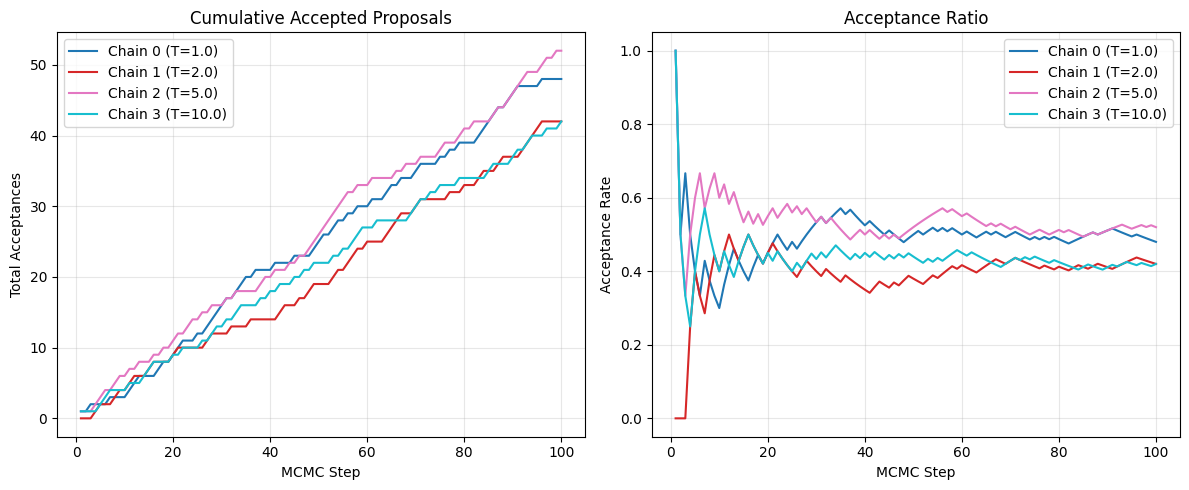

In [31]:
import matplotlib.pyplot as plt

# Compute cumulative acceptances and ratio across the chain dimension
# accepts has shape: (N_chains, N_steps)
cumulative_accepts = np.cumsum(accepts, axis=1)

# To calculate ratio, we need step numbers: 1 to N_steps
step_indices = np.arange(1, N_steps + 1)
acceptance_ratios = cumulative_accepts / step_indices[None, :]

# Set up the plot grid
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Use a colormap distinct for each chain
colors = plt.cm.tab10(np.linspace(0, 1, N_chains))

# Plot 1: Cumulative Acceptances
for i in range(N_chains):
    axes[0].plot(
        step_indices,
        cumulative_accepts[i],
        label=f"Chain {i} (T={temperatures_j[i]:.1f})",
        color=colors[i],
    )
axes[0].set_title("Cumulative Accepted Proposals")
axes[0].set_xlabel("MCMC Step")
axes[0].set_ylabel("Total Acceptances")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Acceptance Ratio over Time
for i in range(N_chains):
    axes[1].plot(
        step_indices,
        acceptance_ratios[i],
        label=f"Chain {i} (T={temperatures_j[i]:.1f})",
        color=colors[i],
    )
axes[1].set_title("Acceptance Ratio")
axes[1].set_xlabel("MCMC Step")
axes[1].set_ylabel("Acceptance Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np

# --- Configuration ---
N_chains = 8
N_steps_per_phase = 50

N_steps_burnin = 100  # Steps to throw away
N_steps_sampling = 1000  # Steps to keep

assert N_steps_burnin % N_steps_per_phase == 0, (
    "Burn-in steps must be a multiple of steps per phase"
)
assert N_steps_sampling % N_steps_per_phase == 0, (
    "Sampling steps must be a multiple of steps per phase"
)
N_phases_burnin = N_steps_burnin // N_steps_per_phase
N_phases_sampling = N_steps_sampling // N_steps_per_phase

temperatures_j = jnp.geomspace(1.0, 20.0, num=N_chains)

# Setup initial constraints
master_key = jax.random.PRNGKey(1234)
setup_key, runtime_key = jax.random.split(master_key)

initial_states = prior(setup_key, num_samples=N_chains)
initial_travel_times = forward_model(initial_states)
vmap_log_L = jax.vmap(log_likelihood_gaussian, in_axes=(None, None, 0))
initial_log_Ls = vmap_log_L(data_obs, data_std, initial_travel_times)


# -------------------------------------------------------------------------
# THE COMPILED PARALLEL TEMPERING ORCHESTRATOR
# -------------------------------------------------------------------------
@jax.jit(static_argnames=["forward_model", "N_steps_per_phase", "N_phases"])
def pt_scan_loop(
    rng_key,
    initial_states,
    initial_log_Ls,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperatures,
    N_steps_per_phase,
    N_phases,
    phase_idx_offset,
):
    keys = jax.random.split(rng_key, N_phases)
    phase_indices = jnp.arange(N_phases) + phase_idx_offset

    # We natively generate base indexes here to keep array lengths statically safe
    left_base_indices = np.arange(0, len(temperatures), 2)

    @scan_tqdm(N_phases, print_rate=1, tqdm_type="auto")
    def pt_phase_body(carry, scan_input):
        i_phase, phase_key, phase_idx = scan_input
        current_states, current_log_Ls = carry

        swap_key, chain_run_key = jax.random.split(phase_key)
        chain_keys = jax.random.split(chain_run_key, len(temperatures))

        # 1. Run local MCMC block (Uses your custom mapped vmap_run_mcmc from earlier)
        (post_mcmc_states, post_mcmc_log_Ls), history = vmap_run_mcmc(
            chain_keys,
            current_states,
            current_log_Ls,
            proposal_dist,
            data_obs,
            data_std,
            forward_model,
            temperatures,
            N_steps_per_phase,
        )

        # 2. Vectorized PT SWAP LOGIC
        # Deterministically flips between Phase Check Pairings [0-1, 2-3] vs [1-2, 3-3(ignored)]
        start_idx = phase_idx % 2

        # Construct pair indices, clipping to prevent Array OOB exceptions natively
        left_idx = jnp.clip(left_base_indices + start_idx, 0, len(temperatures) - 1)
        right_idx = jnp.clip(left_idx + 1, 0, len(temperatures) - 1)

        beta = 1.0 / temperatures
        log_L_left = post_mcmc_log_Ls[left_idx]
        log_L_right = post_mcmc_log_Ls[right_idx]
        beta_left = beta[left_idx]
        beta_right = beta[right_idx]

        log_swap_ratio = (log_L_left - log_L_right) * (beta_right - beta_left)
        log_u = jnp.log(
            jax.random.uniform(swap_key, shape=(left_base_indices.shape[0],))
        )

        do_swap = log_u < log_swap_ratio

        states_left = post_mcmc_states[left_idx]
        states_right = post_mcmc_states[right_idx]

        # Broadcast where condition along grids using specialized axes mapping
        vmap_where = jax.vmap(jnp.where, in_axes=(0, 0, 0))
        new_states_left = vmap_where(do_swap, states_right, states_left)
        new_states_right = vmap_where(do_swap, states_left, states_right)

        new_log_L_left = jnp.where(do_swap, log_L_right, log_L_left)
        new_log_L_right = jnp.where(do_swap, log_L_left, log_L_right)

        # Reconstruct the full 4D stacked tensors
        new_states = post_mcmc_states.at[left_idx].set(new_states_left)
        new_states = new_states.at[right_idx].set(new_states_right)

        new_log_Ls = post_mcmc_log_Ls.at[left_idx].set(new_log_L_left)
        new_log_Ls = new_log_Ls.at[right_idx].set(new_log_L_right)

        # Calculate successful swaps (ignoring duplicate "clones" we make to bypass OOB problems)
        num_swaps = jnp.sum(jnp.where(left_idx != right_idx, do_swap, False))

        samples_j, log_L_j, accepts_j = history
        history_out = (samples_j, log_L_j, accepts_j, num_swaps)

        return (new_states, new_log_Ls), history_out

    return jax.lax.scan(
        pt_phase_body,
        (initial_states, initial_log_Ls),
        (jnp.arange(N_phases), keys, phase_indices),
    )


# -------------------------------------------------------------------------
# EXECUTION
# -------------------------------------------------------------------------
print(f"Starting Fully Compiled Parallel Tempering...")
print(f"Phase chunk target: {N_steps_per_phase} consecutive steps")
print(f"Burn-in: {N_steps_burnin} total steps")
print(f"Sampling: {N_steps_sampling} total steps\n")

burnin_run_key, sampling_run_key = jax.random.split(runtime_key)

# 1. BURN-IN
print("Compiling and executing Burn-in...")
burnin_carry, burnin_hist = pt_scan_loop(
    burnin_run_key,
    initial_states,
    initial_log_Ls,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperatures_j,
    N_steps_per_phase,
    N_phases=N_phases_burnin,
    phase_idx_offset=0,
)
_, _, _, burnin_swaps = burnin_hist  # Throwing away matrices
print(f"Burn-in successful block swaps: {burnin_swaps.tolist()}")

# 2. SAMPLING (Compiles automatically into dynamic graph the first time N_phases_sampling invokes)
print("Compiling and executing Sampling...")
sampling_carry, sampling_hist = pt_scan_loop(
    sampling_run_key,
    burnin_carry[0],
    burnin_carry[1],
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperatures_j,
    N_steps_per_phase,
    N_phases=N_phases_sampling,
    phase_idx_offset=N_phases_burnin,
)
samples_j, log_L_j, accepts_j, sampling_swaps = sampling_hist
print(f"Sampling successful block swaps: {sampling_swaps.tolist()}")

# -------------------------------------------------------------------------
# FORMAT ARRAY HISTORIES BACK NATIVE
# -------------------------------------------------------------------------
# History shape is natively returned mapped as: (N_phases, N_chains, N_steps_per_phase, nx, ny)
# We flatten phases and blocks into the chronological continuous timeline: (N_chains, Total_Steps, nx, ny)

final_samples = jnp.swapaxes(samples_j, 0, 1).reshape(
    N_chains, -1, *samples_j.shape[3:]
)
final_log_Ls = jnp.swapaxes(log_L_j, 0, 1).reshape(N_chains, -1)
final_accepts = jnp.swapaxes(accepts_j, 0, 1).reshape(N_chains, -1)

# Pass off to CPU memory as standard numpy
final_samples = np.array(final_samples)
final_log_Ls = np.array(final_log_Ls)
final_accepts = np.array(final_accepts)

print(f"\nFinal pipeline completed!")
print(f"Total saved samples array: {final_samples.shape}")
print(
    f"Total acceptances handled per chain (post-burnin): {np.sum(final_accepts, axis=1)}"
)

Starting Fully Compiled Parallel Tempering...
Phase chunk target: 50 consecutive steps
Burn-in: 100 total steps
Sampling: 1000 total steps

Compiling and executing Burn-in...


Running for 2 iterations:   0%|          | 0/2 [00:00<?, ?it/s]

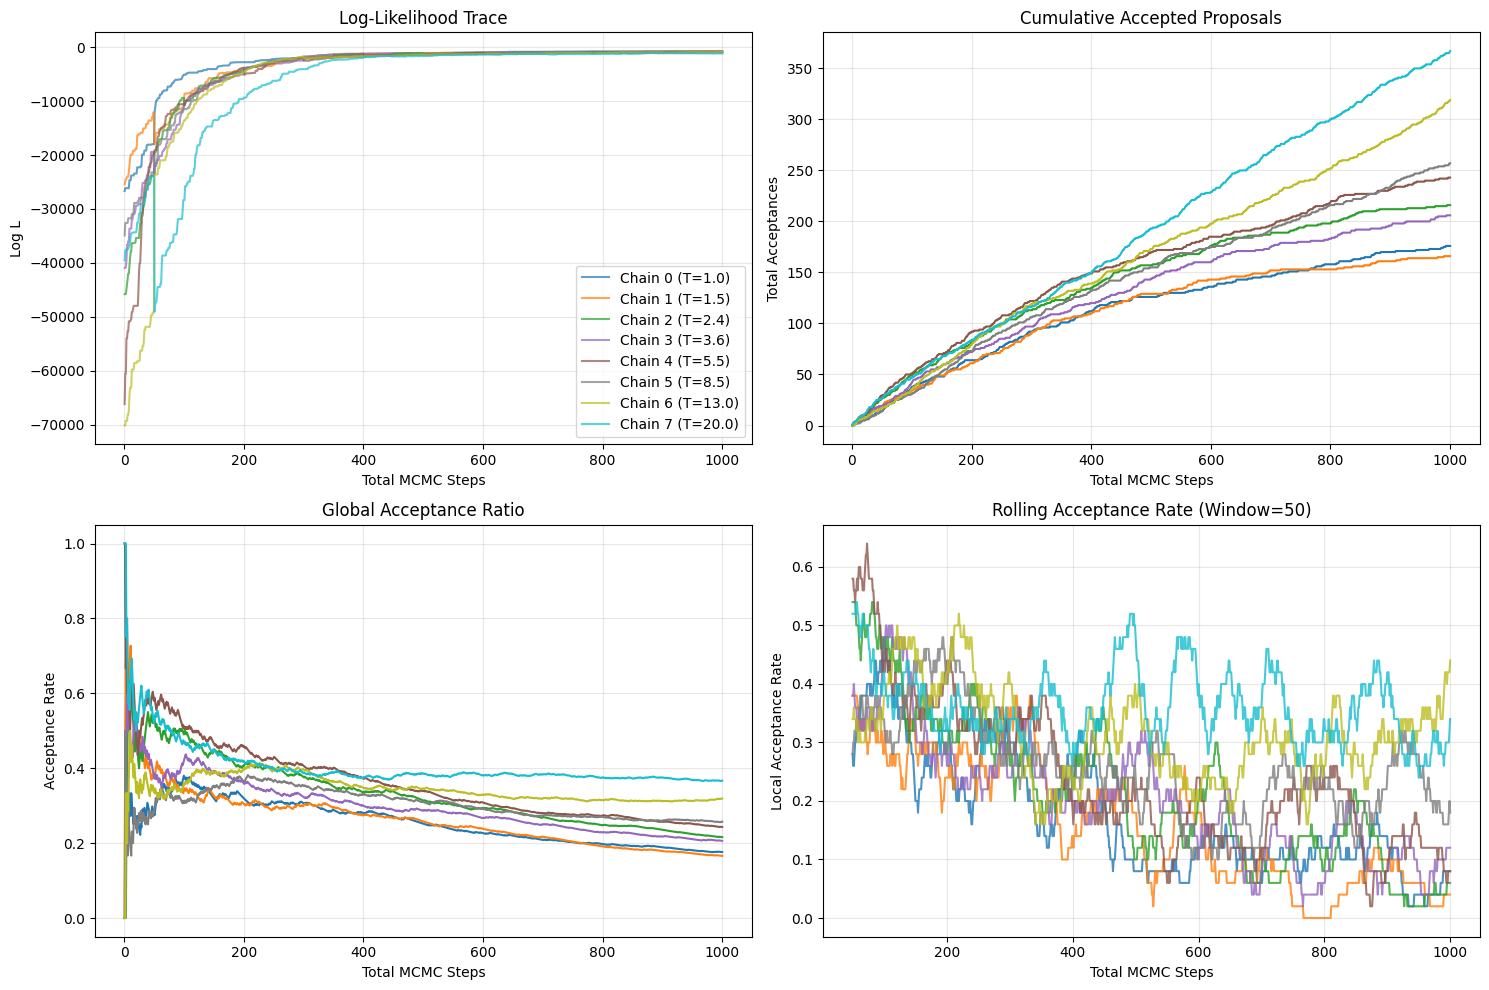

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Total steps across all phases
total_steps = final_accepts.shape[1]
step_indices = np.arange(1, total_steps + 1)

# Compute cumulative acceptances and global ratio across the chain dimension
cumulative_accepts = np.cumsum(final_accepts, axis=1)
acceptance_ratios = cumulative_accepts / step_indices[None, :]

# Compute Windowed (Rolling) Acceptance Rate
window_size = min(50, total_steps)  # 50 steps, or max steps if fewer
window_steps = np.arange(window_size, total_steps + 1)

# Set up the plot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Use a colormap distinct for each chain
colors = plt.cm.tab10(np.linspace(0, 1, N_chains))

# Plot 1: Log-Likelihood Trace
for i in range(N_chains):
    axes[0].plot(
        step_indices,
        final_log_Ls[i],
        alpha=0.7,
        label=f"Chain {i} (T={temperatures_j[i]:.1f})",
        color=colors[i],
    )
axes[0].set_title("Log-Likelihood Trace")
axes[0].set_xlabel("Total MCMC Steps")
axes[0].set_ylabel("Log L")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cumulative Acceptances
for i in range(N_chains):
    axes[1].plot(
        step_indices, cumulative_accepts[i], label=f"Chain {i}", color=colors[i]
    )
axes[1].set_title("Cumulative Accepted Proposals")
axes[1].set_xlabel("Total MCMC Steps")
axes[1].set_ylabel("Total Acceptances")
axes[1].grid(True, alpha=0.3)

# Plot 3: Global Acceptance Ratio (Cumulative)
for i in range(N_chains):
    axes[2].plot(
        step_indices, acceptance_ratios[i], label=f"Chain {i}", color=colors[i]
    )
axes[2].set_title("Global Acceptance Ratio")
axes[2].set_xlabel("Total MCMC Steps")
axes[2].set_ylabel("Acceptance Rate")
axes[2].grid(True, alpha=0.3)

# Plot 4: Windowed Acceptance Ratio
for i in range(N_chains):
    # Rolling mean using 1D convolution
    windowed_acc = np.convolve(
        final_accepts[i], np.ones(window_size) / window_size, mode="valid"
    )
    axes[3].plot(
        window_steps, windowed_acc, alpha=0.8, label=f"Chain {i}", color=colors[i]
    )
axes[3].set_title(f"Rolling Acceptance Rate (Window={window_size})")
axes[3].set_xlabel("Total MCMC Steps")
axes[3].set_ylabel("Local Acceptance Rate")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

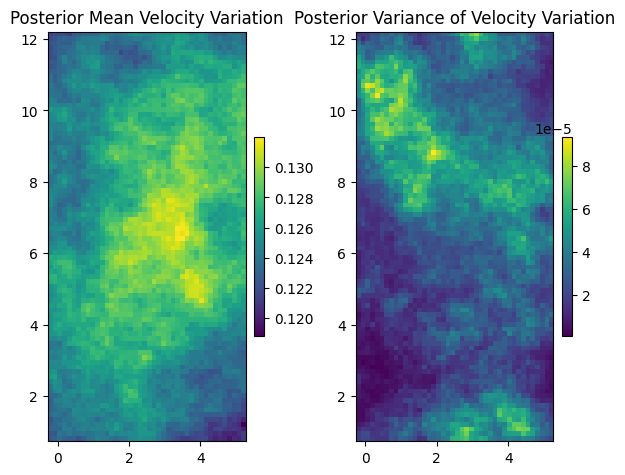

In [ ]:
samples.shape
samples_mean = np.mean(samples, axis=(0, 1))
samples_var = np.var(samples, axis=(0, 1))

plt.figure(figsize=(6, 8))
plt.subplot(1, 2, 1)
plt.imshow(
    samples_mean.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Posterior Mean Velocity Variation")
plt.subplot(1, 2, 2)
plt.imshow(
    samples_var.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Posterior Variance of Velocity Variation")
plt.tight_layout()

In [ ]:
raise NotImplementedError(
    "This is just a demo of how to set up the parallel chains. You can now experiment with different temperatures, proposal distributions, or even implement swap steps between chains for parallel tempering!"
)

NotImplementedError: This is just a demo of how to set up the parallel chains. You can now experiment with different temperatures, proposal distributions, or even implement swap steps between chains for parallel tempering!

In [ ]:
# Try extended metropolis

seeder = gs.random.MasterRNG(20170519)

N_steps = 3
m_current = srf.structured((x, y), seed=seeder())
log_L_current = log_likelihood_gaussian(data_obs, data_std, forward_model(m_current))
for i in range(N_steps):
    m_proposal = srf.structured((x, y), seed=seeder())
    log_L_proposal = log_likelihood_gaussian(
        data_obs, data_std, forward_model(m_proposal)
    )

    log_acceptance_ratio = log_L_proposal - log_L_current
    if np.log(np.random.rand()) < log_acceptance_ratio:
        m_current = m_proposal
        log_L_current = log_L_proposal

NameError: name 'srf' is not defined

In [ ]:
from nanopinv.sampler import ExtendedMetropolisSampler, SRFProposalDistribution

rng = np.random.default_rng(20170519)
rng_accept = rng.spawn(1)[0]

temperature = 1.0

In [ ]:
proposal_dist = SRFProposalDistribution(
    srf=srf, r=[x, y], step_size=0.06, rng=rng.spawn(1)[0]
)

state_current = proposal_dist.propose(state_current=None)
travel_times_current = forward_model(state_current)
log_L_current = log_likelihood_gaussian(data_obs, data_std, travel_times_current)

In [ ]:
samples = []
data = []
N_steps = 2500
N_done = 0
N_accepted = 0
for i in trange(N_steps):
    state_proposal = proposal_dist.propose(state_current=state_current)
    print(state_proposal.shape)
    if not np.all(state_proposal > 0):
        print("Proposal has negative values, rejecting.")
        continue
    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    # print(f"log_ratio: {log_ratio}")
    log_P_accept = min(0.0, log_ratio)
    P_accept = np.exp(log_P_accept)
    # print(f"log_P_accept: {log_P_accept}")
    # print(f"P_accept: {P_accept}")

    if rng_accept.random() < P_accept:
        state_current = state_proposal
        log_L_current = log_L_proposal
        N_accepted += 1

    samples.append(state_current.copy())
    N_done += 1

    data.append(
        {
            "step": N_done,
            "log_P_accept": log_P_accept,
            "P_accept": P_accept,
            "accepted": N_accepted,
            "acceptance_rate": N_accepted / N_done,
        }
    )

  0%|          | 0/2500 [00:00<?, ?it/s]

TypeError: missing a required argument: 'key'

In [ ]:
from nanopinv.sampler_jax import ProposalDistribution

samples = []
data = []
N_steps = 2500
N_done = 0
N_accepted = 0

temperature = 1.0

rng_key = jax.random.PRNGKey(0)

rng_key, initial_key = jax.random.split(rng_key)

proposal_dist = ProposalDistribution(dist=prior, step_size=0.1)
state_current = prior(initial_key)
log_L_current = log_likelihood_gaussian(
    data_obs, data_std, forward_model(state_current)
)


@jax.jit(static_argnames=["forward_model"])
def do_step(
    key,
    state_current,
    log_L_current,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
):
    proposal_key, accept_key = jax.random.split(key)

    state_proposal = proposal_dist.propose(
        key=proposal_key, state_current=state_current
    )

    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    log_P_accept = jnp.minimum(0.0, log_ratio)
    P_accept = jnp.exp(log_P_accept)

    accept = jax.random.uniform(accept_key) < P_accept

    state_next = jnp.where(accept[None, None], state_proposal, state_current)
    log_L_next = jnp.where(accept, log_L_proposal, log_L_current)

    return state_next, log_L_next, accept


# LOOP_STEPSIZE = 10
# for i in trange(N_steps):
#     new_keys = jax.random.split(rng_key, num=LOOP_STEPSIZE + 1)
#     rng_key = new_keys[0]
#     iteration_keys = new_keys[1:]

#     state_current, log_L_current, accept = do_N_step(
#         iteration_keys,
#         state_current,
#         log_L_current,
#         proposal_dist,
#         data_obs,
#         data_std,
#         forward_model,
#         temperature,
#     )

#     N_accepted += jnp.sum(accept)
#     N_done += 1

#     samples.append(state_current.copy())

#     data.append(
#         {
#             "step": N_done,
#             "accepted": N_accepted,
#             "acceptance_rate": N_accepted / N_done,
#         }
#     )

for i in trange(N_steps):
    rng_key, iteration_key = jax.random.split(rng_key)
    state_current, log_L_current, accept = do_step(
        rng_key,
        state_current,
        log_L_current,
        proposal_dist,
        data_obs,
        data_std,
        forward_model,
        temperature,
    )

    N_accepted += jnp.sum(accept)
    N_done += 1

    samples.append(state_current.copy())

    data.append(
        {
            "step": N_done,
            "accepted": N_accepted,
            "acceptance_rate": N_accepted / N_done,
        }
    )


# for i in trange(N_steps):
#     rng_key, proposal_key, accept_key = jax.random.split(rng_key, num=3)
#     state_proposal = proposal_dist.propose(key=proposal_key, state_current=state_current)
#     if not np.all(state_proposal > 0):
#         print("Proposal has negative values, rejecting.")
#         continue
#     travel_times_proposal = forward_model(state_proposal)
#     log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

#     log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
#     # print(f"log_ratio: {log_ratio}")
#     log_P_accept = min(0.0, log_ratio)
#     P_accept = np.exp(log_P_accept)
#     # print(f"log_P_accept: {log_P_accept}")
#     # print(f"P_accept: {P_accept}")

#     if jax.random.uniform(accept_key) < P_accept:
#         state_current = state_proposal
#         log_L_current = log_L_proposal
#         N_accepted += 1

#     samples.append(state_current.copy())
#     N_done += 1

#     data.append({
#         "step": N_done,
#         "log_P_accept": log_P_accept,
#         "P_accept": P_accept,
#         "accepted": N_accepted,
#         "acceptance_rate": N_accepted / N_done,
#     })

 51%|█████     | 1273/2500 [01:56<01:52, 10.94it/s]


KeyboardInterrupt: 

In [ ]:
%load_ext line_profiler


def mcmc_loop_profile(
    proposal_dist, state_current, log_L_current, temperature, rng_accept, N_steps=50
):
    """Profile target for line_profiler."""
    samples = []
    data = []
    N_done = 0
    N_accepted = 0

    for i in range(N_steps):
        state_proposal = proposal_dist.propose(state_current=state_current)
        travel_times_proposal = forward_model(state_proposal)
        log_L_proposal = log_likelihood_gaussian(
            data_obs, data_std, travel_times_proposal
        )

        log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
        log_P_accept = min(0.0, log_ratio)
        P_accept = np.exp(log_P_accept)

        if rng_accept.random() < P_accept:
            state_current = state_proposal
            log_L_current = log_L_proposal
            N_accepted += 1

        samples.append(state_current.copy())
        N_done += 1

        data.append(
            {
                "step": N_done,
                "log_likelihood": log_L_current,
                "accepted": N_accepted,
                "acceptance_rate": N_accepted / N_done,
            }
        )

    return samples, data, N_accepted, N_done


# # Profile the loop and proposal method
# print("=== LINE PROFILER: MCMC Loop ===")
# %lprun -f forward_model -f mcmc_loop_profile mcmc_loop_profile(proposal_dist, state_current, log_L_current, temperature, rng_accept, N_steps=50)

# print("\n=== LINE PROFILER: Propose Method ===")
# %lprun -f proposal_dist.propose mcmc_loop_profile(proposal_dist, state_current, log_L_current, temperature, rng_accept, N_steps=10)

# print("\n=== Diagnostics ===")
# print(f"Grid shape: {state_current.shape}")
# print(f"Grid size (elements): {state_current.size}")
# print(f"Proposal step_size: {proposal_dist.step_size}")
# print(f"# Unique sources: {len(np.unique(sources, axis=0))}")

In [ ]:
samples_arr = np.array(samples)

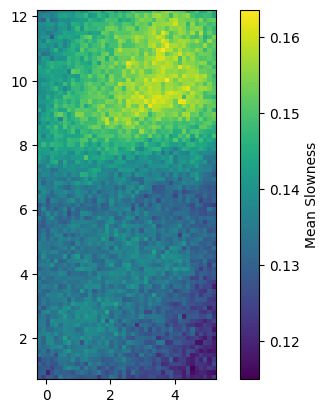

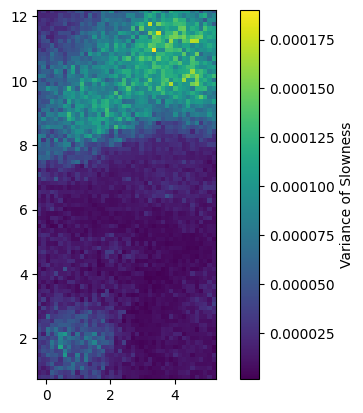

In [ ]:
mean_samples = np.mean(samples_arr, axis=0)
var_samples = np.var(samples_arr, axis=0)

plt.figure()
plt.imshow(
    mean_samples.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(label="Mean Slowness")

plt.figure()
plt.imshow(
    var_samples.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(label="Variance of Slowness")

c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\seaborn\_core\data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\seaborn\_core\data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


<Axes: xlabel='step', ylabel='acceptance_rate'>

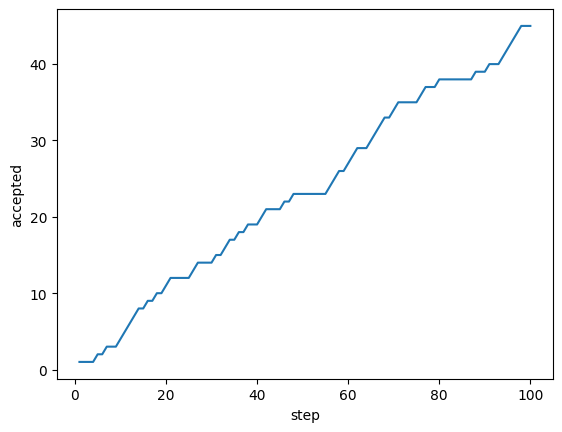

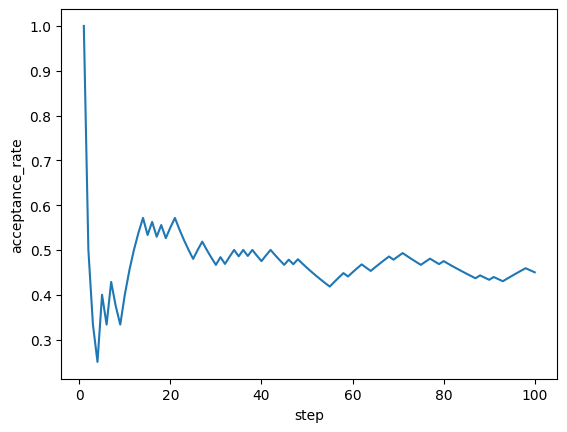

In [ ]:
import polars as pl

df = pl.DataFrame(data)
df

sns.lineplot(data=df, x="step", y="accepted")
plt.figure()
sns.lineplot(data=df, x="step", y="acceptance_rate")

In [ ]:
import jax.lax as lax


# First, define your single step exactly as you did, slightly modified to
# package the inputs and outputs structurally for lax.scan
@jax.jit(static_argnames=["forward_model"])
def mcmc_scan_body(
    carry,  # The current state that carries over chain steps
    step_key,  # The specific pre-split rng key for this one iteration
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
):
    # Unpack the carry
    state_current, log_L_current = carry

    proposal_key, accept_key = jax.random.split(step_key)

    state_proposal = proposal_dist.propose(
        key=proposal_key, state_current=state_current
    )

    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    log_P_accept = jnp.minimum(0.0, log_ratio)
    P_accept = jnp.exp(log_P_accept)

    accept = jax.random.uniform(accept_key) < P_accept

    state_next = jnp.where(accept, state_proposal, state_current)
    log_L_next = jnp.where(accept, log_L_proposal, log_L_current)

    # Package the updated state for the next step
    new_carry = (state_next, log_L_next)

    # Let's save the current state and whether we accepted as the history arrays
    history_output = (state_next, log_L_next, accept)

    return new_carry, history_output


# Now, build wrapper that JIT compiles the full loop execution
@jax.jit(static_argnames=["forward_model", "N_steps"])
def run_mcmc_chain(
    rng_key,
    initial_state,
    initial_log_L,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
    N_steps,
):
    # Pre-generate ALL random keys for the entire chain simultaneously avoiding sequential splits
    keys = jax.random.split(rng_key, N_steps)

    # We must explicitly freeze static objects into the scan closure
    def scan_fn(carry, step_key):
        return mcmc_scan_body(
            carry,
            step_key,
            proposal_dist,
            data_obs,
            data_std,
            forward_model,
            temperature,
        )

    initial_carry = (initial_state, initial_log_L)

    # jax.lax.scan sequentially applies `scan_fn`.
    # It passes initial_carry and keys[0], gets new_carry_1 and out_1.
    # It passes new_carry_1 and keys[1], gets new_carry_2 and out_2...
    final_carry, history = lax.scan(scan_fn, initial_carry, keys)

    return final_carry, history


# --- RUNNING THE CHAIN ---
N_steps = 2500

state_current = prior(initial_key)
log_L_current = log_likelihood_gaussian(
    data_obs, data_std, forward_model(state_current)
)

final_carry, (samples_j, log_L_j, accepts_j) = run_mcmc_chain(
    rng_key,
    state_current,
    log_L_current,
    proposal_dist,
    data_obs,
    data_std,
    forward_model,
    temperature,
    N_steps,
)

# Convert mapped history into numpy
samples = np.array(samples_j)
log_L_history = np.array(log_L_j)
accepts = np.array(accepts_j)

# You can reconstruct your stats DataFrame easily because
# standard numpy vector operations are faster than loop appends anyway
steps = np.arange(1, N_steps + 1)
cumulative_accepts = np.cumsum(accepts)

data = []
for i in range(N_steps):
    data.append(
        {
            "step": steps[i],
            "accepted": cumulative_accepts[i],
            "acceptance_rate": cumulative_accepts[i] / steps[i],
        }
    )

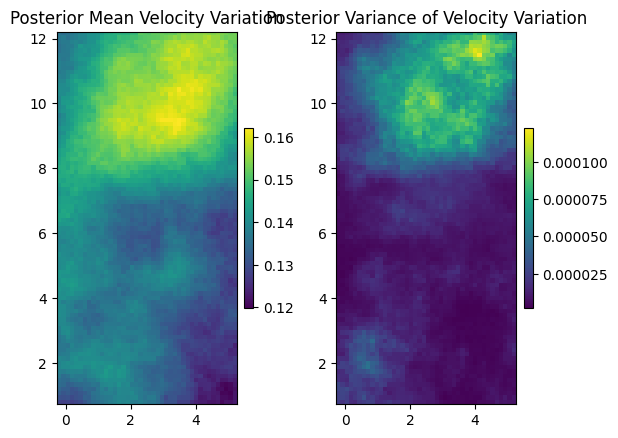

In [ ]:
samples.shape
samples_mean = np.mean(samples, axis=(0))
samples_var = np.var(samples, axis=(0))

plt.figure(figsize=(6, 8))
plt.subplot(1, 2, 1)
plt.imshow(
    samples_mean.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Posterior Mean Velocity Variation")
plt.subplot(1, 2, 2)
plt.imshow(
    samples_var.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Posterior Variance of Velocity Variation")
plt.tight_layout()

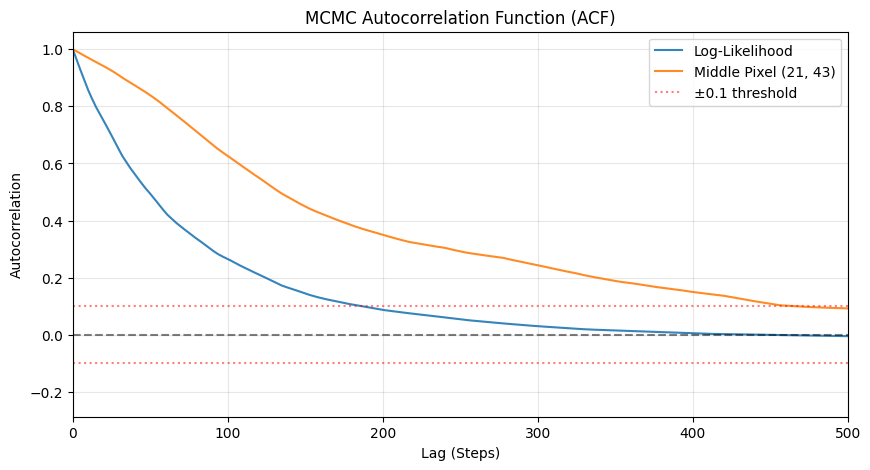

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def compute_autocorr(x):
    """Computes the 1D normalized autocorrelation function."""
    x = x - np.mean(x)
    # Compute full cross-correlation
    corr = np.correlate(x, x, mode="full")
    # Keep only the second half (lags >= 0)
    corr = corr[corr.size // 2 :]
    # Normalize by the 0-lag (which is the variance)
    return corr / corr[0]


# 1. ACF of the Log-Likelihood
acf_log_L = compute_autocorr(log_L_history)

# 2. ACF of a specific pixel in the middle of the grid
mid_x, mid_y = samples.shape[1] // 2, samples.shape[2] // 2
pixel_trace = samples[:, mid_x, mid_y]
acf_pixel = compute_autocorr(pixel_trace)

# 3. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(acf_log_L, label="Log-Likelihood", alpha=0.9)
plt.plot(acf_pixel, label=f"Middle Pixel ({mid_x}, {mid_y})", alpha=0.9)

# Formatting
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
# Add bounds to indicate when correlation becomes negligible
plt.axhline(0.1, color="red", linestyle=":", alpha=0.5, label="±0.1 threshold")
plt.axhline(-0.1, color="red", linestyle=":", alpha=0.5)

plt.xlabel("Lag (Steps)")
plt.ylabel("Autocorrelation")
plt.title("MCMC Autocorrelation Function (ACF)")
plt.legend()

# Zoom in on the early steps where the drop-off happens
# You can adjust this xlim depending on how slow the mixing is
plt.xlim(0, min(500, len(log_L_history)))
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
forward = forward_model(samples[-1, :, :])

forwards = forward_model(samples[::10])

In [ ]:
forwards_mean = np.mean(forwards, axis=0)
forwards_var = np.var(forwards, axis=0)
forwards_ci = 1.96 * np.sqrt(forwards_var)
forwards_ub = forwards_mean + forwards_ci
forwards_lb = forwards_mean - forwards_ci

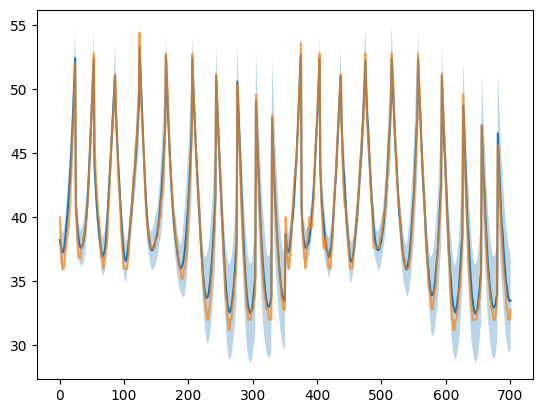

In [ ]:
plt.plot(forwards_mean, label="Mean Forward Prediction")
plt.fill_between(
    np.arange(len(forwards_mean)),
    forwards_lb,
    forwards_ub,
    alpha=0.3,
    label="95% Credible Interval",
)
plt.plot(data_obs, alpha=0.7)

In [ ]:
import numpy as np

# 1. Thin your true posterior to evaluate network efficiency
thinned_samples = posterior_samples[500::10]  # Discard some burn-in if needed & thin
forwards = forward_model(thinned_samples)
forwards_mean = np.mean(forwards, axis=0)

# 2. Add random observational noise to the simulated travel times mathematically
noisy_forwards = forwards + np.random.normal(0, data_std, size=forwards.shape)

# 3. Pull Empirical 95% Interval
predictive_lb = np.percentile(noisy_forwards, 2.5, axis=0)
predictive_ub = np.percentile(noisy_forwards, 97.5, axis=0)

# --- Plotting ---
plt.figure(figsize=(12, 6))

plt.fill_between(
    np.arange(len(forwards_mean)),
    predictive_lb,
    predictive_ub,
    color="gray",
    alpha=0.3,
    label="95% Predictive Interval (Includes Noise)",
)

plt.plot(forwards_mean, color="blue", label="Mean Prediction")
plt.plot(
    data_obs,
    color="red",
    marker=".",
    linestyle="none",
    alpha=0.7,
    label="Observed Data",
)
plt.xlabel("Data Index")
plt.ylabel("Travel Time")
plt.legend()
plt.show()

NameError: name 'posterior_samples' is not defined

TODO: 

Read [](file:///c%3A/Users/jeppe/Documents/MEGA/Base/DTU/30760%20Inverse%20Problems%20and%20Machine%20Learning%20in%20Earth%20and%20Space%20Physics/nanopinv/nanopinv)

Read [](file:///c%3A/Users/jeppe/Documents/MEGA/Base/DTU/30760%20Inverse%20Problems%20and%20Machine%20Learning%20in%20Earth%20and%20Space%20Physics/nanopinv/nanopinv/sampler_jax.py)

I have reviewed the entire notebook and the associated mathematical implementation. While your Parallel Tempering and JAX compilations are extremely solid, there are **three critical bugs** involving how you transition from PT MCMC sampling to downstream inference/plotting. 

These will lead to severely incorrect scientific outputs (and broken arrays) if not corrected.

### 1. Mixing High-Temperature Chains into the Posterior (Critical Scientific Bug)
In Parallel Tempering, **only the base chain ($T=1.0$) represents the true posterior distribution.** The higher-temperature chains are mathematically flattened to explore wide spaces and are invalid for inference plotting.

By using `samples = np.array(samples_j)` or the full `final_samples` array from `pt_scan_loop`, you end up with a 4D array: `(N_chains, Total_Steps, nx, ny)`. 
If you simply evaluate `np.mean(final_samples, axis=(0, 1))`, you are averaging the "hot" physics in with the real physics, completely destroying your spatial certainty.

**The Fix:** You must exclusively extract `Chain 0` (since `temperatures_j[0] = 1.0`) before calculating stats or forwards:
```python
# Extract the T=1.0 cold chain ONLY
posterior_samples = final_samples[0]  # Shape: (Total_Steps, nx, ny)

samples_mean = np.mean(posterior_samples, axis=0) # Now shape (nx, ny)
samples_var = np.var(posterior_samples, axis=0)
```

### 2. Slicing the Wrong Axis for `forwards` (Code Crashing Bug)
If you evaluate `forwards = forward_model(final_samples[::10])`, you will mistakenly slice the `N_chains` axis, yielding a chunk of 4D arrays. If your `build_time_travel_points` is strictly waiting for 3D `(batch, nx, ny)`, it will throw an unreadable nested XLA shape exception.

**The Fix:** Slice the dimension of the isolated `posterior_samples`:
```python
# Safely thins the time steps from the T=1.0 chain
forwards = forward_model(posterior_samples[::10]) 
```

### 3. Adding Standard Deviations Linearly (Mathematical Metric Bug)
In the prediction bounds you shared:
`predictive_lb = forwards_lb_model - (1.96 * data_std)`
Standard deviations do not algebraically add linearly—*variances* do ($\sigma_{total} = \sqrt{\sigma_{model}^2 + \sigma_{noise}^2}$). Adding $1.96 \cdot \sigma$ linearly significantly **overestimates** your uncertainty bounds. 

Furthermore, if the model bounds are not perfectly Gaussian, you distort the distribution. In MCMC, the gold standard for "Posterior Predictive Uncertainty" is physically simulating the noise directly onto the prediction tensor before finding percentiles.

**The Fix:**
```python
import numpy as np

# 1. Thin your true posterior to evaluate network efficiency 
thinned_samples = posterior_samples[500::10] # Discard some burn-in if needed & thin
forwards = forward_model(thinned_samples)
forwards_mean = np.mean(forwards, axis=0)

# 2. Add random observational noise to the simulated travel times mathematically
noisy_forwards = forwards + np.random.normal(0, data_std, size=forwards.shape)

# 3. Pull Empirical 95% Interval
predictive_lb = np.percentile(noisy_forwards, 2.5, axis=0)
predictive_ub = np.percentile(noisy_forwards, 97.5, axis=0)

# --- Plotting ---
plt.figure(figsize=(12, 6))

plt.fill_between(
    np.arange(len(forwards_mean)),
    predictive_lb,
    predictive_ub,
    color='gray',
    alpha=0.3,
    label="95% Predictive Interval (Includes Noise)"
)

plt.plot(forwards_mean, color='blue', label="Mean Prediction")
plt.plot(data_obs, color='red', marker='.', linestyle='none', alpha=0.7, label="Observed Data")
plt.xlabel("Data Index"); plt.ylabel("Travel Time"); plt.legend()
plt.show()
```

### 4. (Sanity Check) JAX Negative Velocities
*Context:* Your Proposal uses a Preconditioned Crank-Nicolson (pCN) update assuming values distribute around `mean = 0.12`. 
Eventually, the tails of these Gaussian mutations will propose negative slownesses/velocities. Since you `jax.jit` the `do_step` execution, if your eikonal solver doesn't safely clip negative values at the compiler level, the matrix will silently spit `NaNs`. Once the likelihood calculates `NaN`, the Parallel Tempering locks onto the NaN indefinitely. 

Just ensure somewhere either inside `propose()` or your Eikonal wrapper you strictly bind the lower floor via `jnp.maximum(tensor, 1e-6)`.